# Brasileirão Série A: probabilidades de resultado (A, D, H)

Competição Campeonato Inteli Módulo 3 2026. O objetivo é estimar, para cada partida do `test.csv`, a probabilidade de vitória do visitante (A), empate (D) e vitória do mandante (H), minimizando o LogLoss multiclasse.

A ideia central do notebook é usar as cotações de fechamento do `train.csv` como alvo de treino. O resultado de uma partida é uma amostra muito ruidosa da probabilidade verdadeira, enquanto a probabilidade implícita do mercado é uma estimativa bem mais estável dessa mesma quantidade. Treinar o modelo para reproduzir o mercado a partir das features reduz a variância dos coeficientes, e isso importa muito em uma base com pouco mais de 3 mil partidas. Como o teste não tem odds, o modelo final depende só das colunas da própria linha.

Regras que o notebook respeita e deixa verificáveis:

- O código usa apenas NumPy, Pandas e Scikit-Learn para modelagem, e Matplotlib para visualização.
- Nenhum dado externo entra no pipeline, tudo vem de `train.csv` e `test.csv`.
- Cada previsão do teste usa somente as colunas da própria linha, e a seção 9 testa isso prevendo linha a linha.
- A validação é temporal, separada por temporada, sem shuffle.
- O placar público não entra em nenhuma decisão, todas as escolhas saem da validação local.

## 1. Setup

In [1]:
import os
import itertools
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import log_loss

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
CLASSES = ["A", "D", "H"]  # ordem alfabetica, a mesma que o log_loss do sklearn usa

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

In [2]:
def find_data_dir():
    # procura os CSVs na variavel de ambiente, na pasta local e no caminho padrao do Kaggle
    candidates = [
        os.environ.get("BRASILEIRAO_DATA"),
        "data",
        ".",
        "/kaggle/input/campeonato-inteli-modulo-3-2026",
    ]
    for c in candidates:
        if c and (Path(c) / "train.csv").exists() and (Path(c) / "test.csv").exists():
            return Path(c)
    raise FileNotFoundError("Coloque train.csv, test.csv e sample_submission.csv na pasta data/")


DATA_DIR = find_data_dir()
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train.shape, "| test:", test.shape, "| sample:", sample.shape)
train.head()

train: (3419, 26) | test: (1725, 22) | sample: (1725, 4)


,Id,Season,Date,Home,Away,elo_home,elo_away,elo_diff,form_pts_home,form_pts_away,form_gf_home,form_ga_home,form_gf_away,form_ga_away,home_form_as_host,away_form_as_visitor,rest_days_home,rest_days_away,season_ppg_home,season_ppg_away,round_n,h2h_home_pts,Res,odd_casa,odd_empate,odd_visitante
0,0,2013,2013-05-25,Vasco,Portuguesa,1506.636452,1486.580590,20.055862,1.6,1.0,1.2,1.4,0.8,1.2,0.4,1.0,174.0,174.0,NaN,NaN,1,3.0,H,1.86,3.44,4.06
1,1,2013,2013-05-25,Vitoria,Internacional,1500.000000,1490.971962,9.028038,NaN,0.2,NaN,NaN,0.0,1.6,NaN,0.8,NaN,174.0,NaN,NaN,1,NaN,D,2.72,3.17,2.52
2,2,2013,2013-05-26,Corinthians,Botafogo RJ,1527.354763,1506.560479,20.794285,2.0,1.0,2.2,1.0,1.8,1.8,2.2,1.2,175.0,176.0,NaN,NaN,1,0.0,D,1.82,3.43,4.21
3,3,2013,2013-05-26,Criciuma,Bahia,1500.000000,1498.594997,1.405003,NaN,2.0,NaN,NaN,1.0,0.8,NaN,1.4,NaN,175.0,NaN,NaN,1,NaN,H,1.72,3.50,4.70
4,4,2013,2013-05-26,Gremio,Nautico,1561.732962,1489.510755,72.222206,2.2,1.4,1.8,1.0,1.2,0.8,1.8,0.4,175.0,175.0,NaN,NaN,1,3.0,H,1.38,4.36,8.19


## 2. Leitura inicial dos dados

Antes de modelar, vale conferir três coisas: a distribuição do resultado por temporada (a vantagem do mandante muda ao longo dos anos), a quantidade de valores ausentes por coluna, e se as temporadas do treino e do teste realmente não se sobrepõem.

In [3]:
seasons = [int(s) for s in sorted(train.Season.unique())]
print("temporadas treino:", seasons)
print("temporadas teste :", [int(s) for s in sorted(test.Season.unique())])
assert train.Season.max() < test.Season.min(), "treino e teste deveriam ser separados no tempo"

dist = train.groupby("Season").Res.value_counts(normalize=True).unstack()[CLASSES]
dist["n"] = train.groupby("Season").size()
print(dist.round(3))

faltantes = pd.DataFrame({"train": train.isna().sum(), "test": test.isna().sum()}).fillna(0).astype(int)
print(faltantes[faltantes.sum(axis=1) > 0])
print("times do teste que nao aparecem no treino:", sorted((set(test.Home) | set(test.Away)) - (set(train.Home) | set(train.Away))))

temporadas treino: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
temporadas teste : [2022, 2023, 2024, 2025, 2026]
Res         A      D      H    n
Season                          
2013    0.232  0.284  0.484  380
2014    0.239  0.242  0.518  380
2015    0.234  0.239  0.526  380
2016    0.219  0.248  0.533  379
2017    0.289  0.271  0.439  380
2018    0.179  0.289  0.532  380
2019    0.258  0.258  0.484  380
2020    0.266  0.284  0.450  380
2021    0.245  0.297  0.458  380
                      train  test
away_form_as_visitor     16     2
form_ga_away              9     2
form_ga_home              7     0
form_gf_away              9     2
form_gf_home              7     0
form_pts_away             9     2
form_pts_home             7     0
h2h_home_pts            656   112
home_form_as_host        16     2
rest_days_away            9     2
rest_days_home            7     0
season_ppg_away          90    50
season_ppg_home          90    50
times do teste que nao aparecem no tr

A frequência de vitória do mandante oscila entre 44% e 53% de uma temporada para outra, e boa parte dessa oscilação é ruído de amostra com 380 jogos. Os valores ausentes se concentram na primeira rodada de cada temporada (`season_ppg`) e em confrontos sem histórico (`h2h_home_pts`), então a imputação pela mediana do treino resolve sem distorcer.

## 3. Alvo: resultado real e probabilidade do mercado

As odds trazem a margem da casa embutida, então a soma dos inversos passa de 1. A forma mais comum de tirar a margem é dividir cada inverso pela soma, mas isso assume que a margem é distribuída de forma proporcional entre os três resultados. Na prática a casa carrega mais margem nos azarões, e a normalização proporcional deixa os favoritos com probabilidade menor do que deveriam ter.

O método da potência corrige isso. Para cada partida ele procura o expoente `k` que faz a soma de `(1/odd)^k` dar exatamente 1, o que tira mais margem de quem tem odd alta. A busca é feita por bisseção em NumPy. A célula abaixo compara os dois métodos pelo LogLoss contra o resultado real.

In [4]:
def onehot(res):
    # matriz n x 3 na ordem A, D, H
    return np.stack([(res == c).to_numpy(dtype=float) for c in CLASSES], axis=1)


def inverse_odds(df):
    return np.stack([1 / df.odd_visitante, 1 / df.odd_empate, 1 / df.odd_casa], axis=1)


def devig_proporcional(Q):
    return Q / Q.sum(axis=1, keepdims=True)


def devig_potencia(Q, n_iter=60):
    lo, hi = np.ones(len(Q)), np.full(len(Q), 3.0)
    for _ in range(n_iter):
        k = (lo + hi) / 2
        soma = (Q ** k[:, None]).sum(axis=1)
        lo, hi = np.where(soma > 1, k, lo), np.where(soma > 1, hi, k)
    P = Q ** ((lo + hi) / 2)[:, None]
    return P / P.sum(axis=1, keepdims=True)


Y_all = onehot(train.Res)
Q_all = inverse_odds(train)
assert np.isfinite(Q_all).all(), "ha partidas sem odds no treino"

print("margem media do mercado        :", round(float(Q_all.sum(axis=1).mean() - 1), 4))
print("LogLoss da frequencia historica:", round(log_loss(train.Res, np.tile(Y_all.mean(0), (len(train), 1)), labels=CLASSES), 4))
print("LogLoss mercado, proporcional  :", round(log_loss(train.Res, devig_proporcional(Q_all), labels=CLASSES), 4))
print("LogLoss mercado, potencia      :", round(log_loss(train.Res, devig_potencia(Q_all), labels=CLASSES), 4))

M_all = devig_potencia(Q_all)


def target(idx, alpha):
    # alpha e o peso do mercado no alvo: 0 usa so o resultado, 1 usa so o mercado
    return alpha * M_all[idx] + (1 - alpha) * Y_all[idx]

margem media do mercado        : 0.0693
LogLoss da frequencia historica: 1.0446
LogLoss mercado, proporcional  : 0.997
LogLoss mercado, potencia      : 0.996


O mercado fica perto de 1.00 no treino, e esse número é a referência do melhor que dá para chegar com informação pública. O modelo com as colunas da base deve ficar acima dele, porque o mercado conhece escalação, lesões e contexto que as features não trazem.

## 4. Features

Toda feature nova sai de operações entre colunas da mesma linha. Não existe `groupby`, `shift`, `rolling`, ordenação por data ou qualquer outra operação que olhe para outra partida. Isso garante por construção a regra de usar só a própria linha do teste.

As escolhas principais são as seguintes:

- **Diferenças mandante menos visitante.** Forma, saldo de gols recente e pontos por jogo entram como diferença, porque o que define o resultado é a distância entre os times, não o nível absoluto de cada um.
- **Módulo da diferença de Elo.** O empate é mais provável quando os times se equivalem, e a regressão multinomial só captura isso se receber uma medida de equilíbrio do confronto.
- **Pontos por jogo com encolhimento.** O `season_ppg` das primeiras rodadas vem de poucos jogos, então a diferença é multiplicada por `jogos / (jogos + 8)` para pesar menos no início da temporada.
- **Descanso limitado.** Os dias de descanso são cortados em 10, porque a pausa longa de início de temporada não carrega a mesma informação que a diferença entre 3 e 6 dias.
- **Nome dos times.** `Home` e `Away` entram como efeito fixo com regularização. O coeficiente de cada time é aprendido só no treino e captura o que o Elo não enxerga, como força de elenco percebida pelo mercado e mando de campo mais forte em alguns estádios.

In [5]:
RAW = ["elo_home", "elo_away", "form_pts_home", "form_pts_away", "form_gf_home", "form_ga_home",
       "form_gf_away", "form_ga_away", "home_form_as_host", "away_form_as_visitor",
       "season_ppg_home", "season_ppg_away"]


def build_features(df):
    # usa SOMENTE colunas da propria linha (operacoes vetorizadas coluna a coluna)
    X = pd.DataFrame(index=df.index)
    X["Home"] = df.Home.astype(str)
    X["Away"] = df.Away.astype(str)
    for c in RAW:
        X[c] = df[c]

    X["elo_diff"] = df.elo_diff
    X["elo_diff_abs"] = df.elo_diff.abs()
    X["elo_mean"] = (df.elo_home + df.elo_away) / 2

    X["form_pts_diff"] = df.form_pts_home - df.form_pts_away
    gd_home = df.form_gf_home - df.form_ga_home
    gd_away = df.form_gf_away - df.form_ga_away
    X["form_gd_diff"] = gd_home - gd_away
    X["form_goals_total"] = df.form_gf_home + df.form_ga_home + df.form_gf_away + df.form_ga_away
    X["venue_form_diff"] = df.home_form_as_host - df.away_form_as_visitor

    jogos = (df.round_n - 1).clip(lower=0)
    X["ppg_diff"] = (df.season_ppg_home - df.season_ppg_away) * jogos / (jogos + 8)

    X["rest_diff"] = df.rest_days_home.clip(0, 10) - df.rest_days_away.clip(0, 10)
    X["short_rest_home"] = (df.rest_days_home <= 3).astype(float)
    X["short_rest_away"] = (df.rest_days_away <= 3).astype(float)

    X["h2h_home_pts"] = df.h2h_home_pts
    X["round_n"] = df.round_n
    return X


FEATURE_SETS = {
    "elo": ["elo_diff"],
    "forca": ["elo_diff", "elo_diff_abs", "ppg_diff", "form_pts_diff", "form_gd_diff"],
    "tudo": ["elo_diff", "elo_diff_abs", "elo_mean", "ppg_diff", "form_pts_diff", "form_gd_diff",
             "form_goals_total", "venue_form_diff", "h2h_home_pts", "rest_diff",
             "short_rest_home", "short_rest_away", "round_n"],
    "bruto": RAW + ["elo_diff_abs", "rest_diff", "h2h_home_pts", "round_n"],
}

X_all = build_features(train)
X_all.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
elo_home,3419.0,1517.187,49.884,1341.795,1482.849,1511.909,1549.742,1708.740
elo_away,3419.0,1517.569,49.981,1346.568,1482.550,1513.256,1550.497,1710.550
form_pts_home,3412.0,1.330,0.615,0.000,0.800,1.400,1.800,3.000
form_pts_away,3410.0,1.406,0.614,0.000,1.000,1.400,1.800,3.000
form_gf_home,3412.0,1.153,0.527,0.000,0.800,1.200,1.400,3.400
form_ga_home,3412.0,1.200,0.517,0.000,0.800,1.200,1.600,5.000
form_gf_away,3410.0,1.198,0.534,0.000,0.800,1.200,1.600,4.000
form_ga_away,3410.0,1.144,0.495,0.000,0.800,1.200,1.400,3.400
home_form_as_host,3403.0,1.739,0.642,0.000,1.400,1.800,2.200,3.000
away_form_as_visitor,3403.0,1.000,0.572,0.000,0.600,1.000,1.400,3.000


## 5. Modelo

O modelo é uma regressão logística multinomial treinada com rótulos suaves. O Scikit-Learn não aceita probabilidade como alvo, então cada partida entra três vezes no treino, uma para cada classe, com `sample_weight` igual à probabilidade alvo daquela classe. Isso minimiza exatamente a entropia cruzada entre a previsão e o alvo suave.

O imputador, o scaler e o encoder de times são ajustados só com o treino. Usar estatísticas do teste para padronizar seria uma forma indireta de olhar outras linhas do teste. Times que não existem no treino recebem efeito zero, e a previsão deles sai só das features numéricas.

In [6]:
class SoftLogit:
    # classificador com alvo suave; kind="hgb" troca a logistica por gradient boosting raso

    def __init__(self, cols, C=0.1, team_fx=False, kind="logit"):
        self.cols, self.C, self.team_fx, self.kind = cols, C, team_fx, kind

    def _design(self, X, fit=False):
        if fit:
            self.imp = SimpleImputer(strategy="median").fit(X[self.cols])
        Z = self.imp.transform(X[self.cols])
        if fit:
            self.sc = StandardScaler().fit(Z)
        Z = self.sc.transform(Z)
        if self.team_fx:
            if fit:
                self.ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(X[["Home", "Away"]])
            Z = np.hstack([Z, self.ohe.transform(X[["Home", "Away"]])])
        return Z

    def fit(self, X, P, w=None):
        Z = self._design(X, fit=True)
        n = len(Z)
        Zr = np.vstack([Z, Z, Z])
        yr = np.repeat(np.arange(3), n)
        wr = P.T.reshape(-1).copy()
        if w is not None:
            wr *= np.tile(np.asarray(w, dtype=float), 3)
        keep = wr > 0
        if self.kind == "logit":
            self.clf = LogisticRegression(C=self.C, max_iter=3000)
        else:
            self.clf = HistGradientBoostingClassifier(
                max_depth=2, learning_rate=0.03, max_iter=300,
                min_samples_leaf=60, l2_regularization=1.0, random_state=SEED)
        self.clf.fit(Zr[keep], yr[keep], sample_weight=wr[keep])
        assert list(self.clf.classes_) == [0, 1, 2]
        return self

    def predict_proba(self, X):
        return self.clf.predict_proba(self._design(X))


def time_weights(s, half_life):
    # peso maior para temporadas recentes; half_life em temporadas, None desliga
    if half_life is None:
        return None
    return (0.5 ** ((s.max() - s) / half_life)).to_numpy()


def fit_cfg(cfg, idx):
    m = SoftLogit(FEATURE_SETS[cfg["fs"]], cfg["C"], cfg["team_fx"], cfg["kind"])
    return m.fit(X_all[idx], target(idx, cfg["alpha"]), time_weights(train.Season[idx], cfg["hl"]))

## 6. Validação temporal

Três cortes de validação rodam para cada configuração, e nenhum deles embaralha as partidas:

- **Walk-forward (`wf`).** Para cada uma das cinco últimas temporadas do treino, o modelo treina com todas as temporadas anteriores e prevê a temporada seguinte.
- **Horizonte longo (`long`).** O modelo treina com as cinco primeiras temporadas e prevê as quatro últimas de uma vez.
- **Horizonte longo 2 (`long2`).** O modelo treina com as quatro primeiras temporadas e prevê as cinco últimas.

Os cortes de horizonte longo imitam melhor a tarefa real, em que o teste vai até cinco anos depois do fim do treino. O critério de seleção (`score`) é a média do LogLoss dos três cortes, sempre medido contra o resultado real. A coluna `soft` mede a entropia cruzada contra o mercado nas mesmas partidas. Ela não entra na seleção, mas tem muito menos ruído e serve para confirmar se uma diferença pequena no `score` é sinal ou sorte.

In [7]:
SPLITS = {
    "wf": [([s for s in seasons if s < v], [v]) for v in seasons[-5:]],
    "long": [(seasons[:5], seasons[5:])],
    "long2": [(seasons[:4], seasons[4:])],
}
for nome, sp in SPLITS.items():
    print(nome, "->", [(f"{tr[0]}-{tr[-1]}", va) for tr, va in sp])


def oof_predict(cfg, splits):
    P = np.full((len(train), 3), np.nan)
    for tr_s, va_s in splits:
        tr = train.Season.isin(tr_s).to_numpy()
        va = train.Season.isin(va_s).to_numpy()
        P[va] = fit_cfg(cfg, tr).predict_proba(X_all[va])
    return P


def cross_entropy(T, P, mask=None):
    ok = ~np.isnan(P[:, 0])
    if mask is not None:
        ok = ok & mask
    return float(-(T[ok] * np.log(np.clip(P[ok], 1e-15, 1))).sum(axis=1).mean())


def ll(P, mask=None):
    return cross_entropy(Y_all, P, mask)


def evaluate(P_by_split):
    out = {k: ll(P) for k, P in P_by_split.items()}
    out["score"] = float(np.mean([out[k] for k in SPLITS]))
    out["soft"] = float(np.mean([cross_entropy(M_all, P) for P in P_by_split.values()]))
    return out


# confere que a metrica manual bate com o log_loss do sklearn na ordem A, D, H
_P = devig_proporcional(Q_all)
assert abs(ll(_P) - log_loss(train.Res, _P, labels=CLASSES)) < 1e-12

# referencias: frequencia historica (so com o passado de cada corte) e mercado
ref = {}
for nome, sp in SPLITS.items():
    Pf = np.full((len(train), 3), np.nan)
    for tr_s, va_s in sp:
        Pf[train.Season.isin(va_s).to_numpy()] = Y_all[train.Season.isin(tr_s).to_numpy()].mean(0)
    ref[nome] = {"frequencia": ll(Pf), "mercado": ll(np.where(np.isnan(Pf), np.nan, M_all))}
P_freq_wf = np.full((len(train), 3), np.nan)
for tr_s, va_s in SPLITS["wf"]:
    P_freq_wf[train.Season.isin(va_s).to_numpy()] = Y_all[train.Season.isin(tr_s).to_numpy()].mean(0)
pd.DataFrame(ref).round(4)

wf -> [('2013-2016', [2017]), ('2013-2017', [2018]), ('2013-2018', [2019]), ('2013-2019', [2020]), ('2013-2020', [2021])]
long -> [('2013-2017', [2018, 2019, 2020, 2021])]
long2 -> [('2013-2016', [2017, 2018, 2019, 2020, 2021])]


,wf,long,long2
frequencia,1.0590,1.0519,1.0599
mercado,1.0016,0.9846,1.0016


In [8]:
grid = []
for fs, C, alpha, hl, team_fx in itertools.product(
        FEATURE_SETS, [0.03, 0.1, 0.2, 0.3, 1.0], [0.0, 0.5, 1.0], [None, 4], [False, True]):
    grid.append(dict(fs=fs, C=C, alpha=alpha, hl=hl, team_fx=team_fx, kind="logit"))
# gradient boosting raso entra so como comparacao
for fs, alpha in itertools.product(["forca", "tudo"], [0.0, 1.0]):
    grid.append(dict(fs=fs, C=np.nan, alpha=alpha, hl=None, team_fx=False, kind="hgb"))

rows = []
for cfg in grid:
    rows.append(dict(cfg, **evaluate({k: oof_predict(cfg, sp) for k, sp in SPLITS.items()})))

res = pd.DataFrame(rows).sort_values("score")
print(len(res), "configuracoes avaliadas")
res.head(15).round(4)

244 configuracoes avaliadas


,fs,C,alpha,hl,team_fx,kind,wf,long,long2,score,soft
215,bruto,0.2,1.0,4.0,True,logit,1.0188,1.0065,1.0216,1.0156,1.0217
227,bruto,0.3,1.0,4.0,True,logit,1.0188,1.0068,1.0218,1.0158,1.0218
203,bruto,0.1,1.0,4.0,True,logit,1.0193,1.0065,1.0217,1.0158,1.0218
201,bruto,0.1,1.0,NaN,True,logit,1.0197,1.0066,1.0218,1.0160,1.0218
213,bruto,0.2,1.0,NaN,True,logit,1.0196,1.0069,1.0219,1.0161,1.0219
155,tudo,0.2,1.0,4.0,True,logit,1.0194,1.0067,1.0227,1.0163,1.0218
167,tudo,0.3,1.0,4.0,True,logit,1.0193,1.0069,1.0228,1.0163,1.0219
225,bruto,0.3,1.0,NaN,True,logit,1.0196,1.0074,1.0221,1.0164,1.0221
143,tudo,0.1,1.0,4.0,True,logit,1.0199,1.0068,1.0227,1.0164,1.0219
239,bruto,1.0,1.0,4.0,True,logit,1.0188,1.0083,1.0226,1.0166,1.0226


### Leitura dos resultados

As tabelas abaixo isolam o efeito de cada decisão, olhando a melhor configuração dentro de cada grupo. A comparação que mais importa é a do `alpha`, porque ela mostra quanto o alvo de mercado melhora em relação a treinar direto no resultado.

In [9]:
logit = res[res.kind == "logit"]
for col in ["alpha", "team_fx", "fs", "C", "hl"]:
    melhor = logit.loc[logit.groupby(col, dropna=False).score.idxmin()]
    print(melhor.set_index(col)[["wf", "long", "long2", "score", "soft"]].round(4), "\n")
print("gradient boosting (comparacao):")
print(res[res.kind == "hgb"][["fs", "alpha", "wf", "long", "long2", "score", "soft"]].round(4))

           wf    long   long2   score    soft
alpha                                        
0.0    1.0280  1.0135  1.0283  1.0232  1.0288
0.5    1.0234  1.0108  1.0243  1.0195  1.0260
1.0    1.0188  1.0065  1.0216  1.0156  1.0217 

             wf    long   long2   score    soft
team_fx                                        
False    1.0225  1.0096  1.0234  1.0185  1.0245
True     1.0188  1.0065  1.0216  1.0156  1.0217 

           wf    long   long2   score    soft
fs                                           
bruto  1.0188  1.0065  1.0216  1.0156  1.0217
elo    1.0198  1.0079  1.0225  1.0167  1.0224
forca  1.0197  1.0071  1.0231  1.0166  1.0219
tudo   1.0194  1.0067  1.0227  1.0163  1.0218 

          wf    long   long2   score    soft
C                                           
0.03  1.0207  1.0078  1.0226  1.0170  1.0228
0.10  1.0193  1.0065  1.0217  1.0158  1.0218
0.20  1.0188  1.0065  1.0216  1.0156  1.0217
0.30  1.0188  1.0068  1.0218  1.0158  1.0218
1.00  1.0188  1.0083  1.02

Três leituras saem dessas tabelas. A primeira é que o alvo de mercado (`alpha = 1`) ganha do resultado real em todos os cortes, que é a hipótese central do notebook. A segunda é que os efeitos de time melhoram o score de forma consistente, enquanto a escolha do conjunto de features numéricas muda o score em cerca de um milésimo, porque quase todo o sinal está na diferença de Elo. A terceira é que o gradient boosting fica atrás da regressão logística, o que é esperado em uma base pequena com relação quase linear entre força e resultado.

### Os efeitos de time sobrevivem a um horizonte de cinco anos?

Essa é a decisão mais arriscada do modelo, porque os elencos mudam e o teste vai até 2026. A célula abaixo treina com dados até um ano de corte e mede, para cada temporada seguinte, quanto o modelo com efeito de time ganha do modelo sem. Se o ganho sumisse com o passar dos anos, o certo seria desligar os efeitos de time.

In [10]:
cfg_com = dict(fs="tudo", C=0.1, alpha=1.0, hl=4, team_fx=True, kind="logit")
cfg_sem = dict(cfg_com, team_fx=False)

linhas = []
for corte in seasons[2:-1]:
    tr = (train.Season <= corte).to_numpy()
    m_com, m_sem = fit_cfg(cfg_com, tr), fit_cfg(cfg_sem, tr)
    for s in [x for x in seasons if x > corte]:
        va = (train.Season == s).to_numpy()
        P_com = np.full((len(train), 3), np.nan)
        P_sem = np.full((len(train), 3), np.nan)
        P_com[va], P_sem[va] = m_com.predict_proba(X_all[va]), m_sem.predict_proba(X_all[va])
        linhas.append(dict(horizonte=s - corte,
                           ganho_resultado=ll(P_sem) - ll(P_com),
                           ganho_mercado=cross_entropy(M_all, P_sem) - cross_entropy(M_all, P_com)))

horiz = pd.DataFrame(linhas).groupby("horizonte").agg(["mean", "count"])
horiz.round(4)

ganho_resultado       ganho_mercado      
                     mean count          mean count
horizonte                                          
1                  0.0035     6        0.0034     6
2                  0.0024     5        0.0027     5
3                  0.0021     4        0.0027     4
4                  0.0016     3        0.0026     3
5                  0.0030     2        0.0022     2
6                  0.0023     1        0.0028     1

O ganho medido contra o mercado fica positivo em todos os horizontes e cai pouco com o tempo, então os efeitos de time ficam no modelo final. O ganho contra o resultado real oscila mais, como esperado, mas aponta na mesma direção.

## 7. Seleção e ensemble

Com cerca de 380 partidas por temporada, o erro padrão do LogLoss fica perto de 0.018, e a diferença entre as melhores configurações é de décimos de milésimo. Escolher uma única vencedora seria ajustar ao ruído da validação. O modelo final é a média das probabilidades das 5 melhores configurações, o que reduz a variância dessa escolha.

Depois do ensemble vem um ajuste de temperatura, que eleva as probabilidades a `1/T` e renormaliza. Com `T > 1` a previsão fica menos confiante, com `T < 1` fica mais confiante. O ajuste só é aplicado se melhorar o score fora da amostra em pelo menos 0.0005, caso contrário `T` fica em 1. A trava existe porque um ganho menor que isso não se distingue de ruído.

In [11]:
TOP_K = 5
top = res[res.kind == "logit"].head(TOP_K)
top_cfgs = [grid[i] for i in top.index]
print(top[["fs", "C", "alpha", "hl", "team_fx", "wf", "long", "long2", "score", "soft"]].round(4))

P_ens = {k: np.mean([oof_predict(cfg, sp) for cfg in top_cfgs], axis=0) for k, sp in SPLITS.items()}
print("\nensemble:", {k: round(v, 4) for k, v in evaluate(P_ens).items()})


def temper(P, T):
    Q = np.clip(P, 1e-12, 1) ** (1 / T)
    return Q / Q.sum(axis=1, keepdims=True)


temps = [round(float(t), 2) for t in np.arange(0.80, 1.31, 0.05)]
t_scores = {T: evaluate({k: temper(P, T) for k, P in P_ens.items()})["score"] for T in temps}
T_best = min(t_scores, key=t_scores.get)
T_FINAL = T_best if t_scores[1.0] - t_scores[T_best] >= 0.0005 else 1.0
print("score por temperatura:", {k: round(v, 4) for k, v in t_scores.items()})
print("melhor T:", T_best, "| ganho:", round(t_scores[1.0] - t_scores[T_best], 5), "| T aplicado:", T_FINAL)

        fs    C  alpha   hl  team_fx      wf    long   long2   score    soft
215  bruto  0.2    1.0  4.0     True  1.0188  1.0065  1.0216  1.0156  1.0217
227  bruto  0.3    1.0  4.0     True  1.0188  1.0068  1.0218  1.0158  1.0218
203  bruto  0.1    1.0  4.0     True  1.0193  1.0065  1.0217  1.0158  1.0218
201  bruto  0.1    1.0  NaN     True  1.0197  1.0066  1.0218  1.0160  1.0218
213  bruto  0.2    1.0  NaN     True  1.0196  1.0069  1.0219  1.0161  1.0219



ensemble: {'wf': 1.0192, 'long': 1.0066, 'long2': 1.0217, 'score': 1.0158, 'soft': 1.0217}
score por temperatura: {0.8: 1.0194, 0.85: 1.0175, 0.9: 1.0163, 0.95: 1.0158, 1.0: 1.0158, 1.05: 1.0161, 1.1: 1.0167, 1.15: 1.0175, 1.2: 1.0185, 1.25: 1.0195, 1.3: 1.0206}
melhor T: 1.0 | ganho: 0.0 | T aplicado: 1.0


      frequencia  modelo  mercado
2017      1.0874  1.0785   1.0696
2018      1.0148  0.9691   0.9336
2019      1.0520  0.9850   0.9632
2020      1.0747  1.0353   1.0287
2021      1.0663  1.0279   1.0128


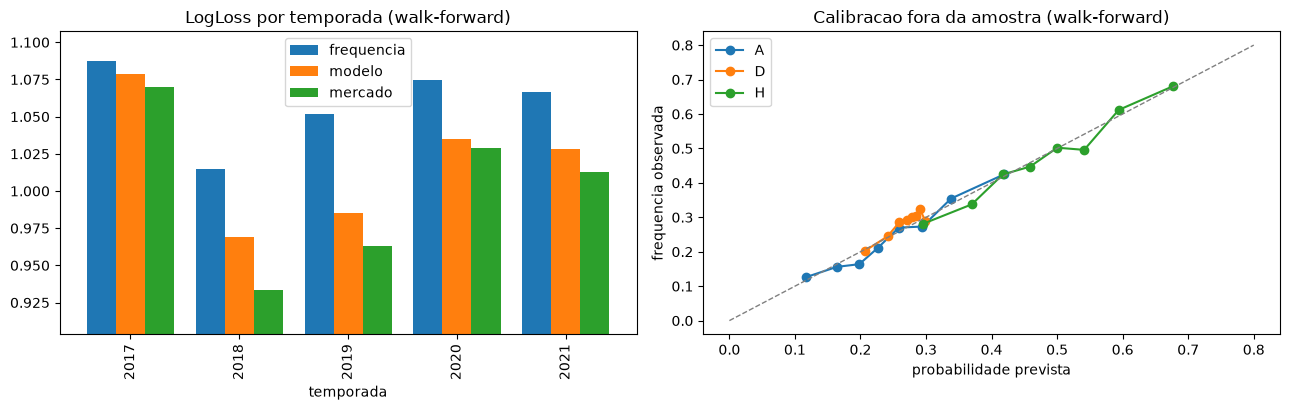

In [12]:
P_val = temper(P_ens["wf"], T_FINAL)
wf_seasons = seasons[-5:]
por_temporada = pd.DataFrame({
    "frequencia": [ll(P_freq_wf, (train.Season == s).to_numpy()) for s in wf_seasons],
    "modelo": [ll(P_val, (train.Season == s).to_numpy()) for s in wf_seasons],
    "mercado": [cross_entropy(Y_all, M_all, (train.Season == s).to_numpy()) for s in wf_seasons],
}, index=wf_seasons)
print(por_temporada.round(4))

wf_mask = ~np.isnan(P_val[:, 0])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
por_temporada.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_ylim(por_temporada.min().min() - 0.03, por_temporada.max().max() + 0.02)
axes[0].set_title("LogLoss por temporada (walk-forward)")
axes[0].set_xlabel("temporada")

# calibracao: probabilidade prevista x frequencia observada, por faixa
for j, c in enumerate(CLASSES):
    p, y = P_val[wf_mask, j], Y_all[wf_mask, j]
    g = pd.DataFrame({"p": p, "y": y}).groupby(pd.qcut(p, 8, duplicates="drop"), observed=True).mean()
    axes[1].plot(g.p, g.y, marker="o", label=c)
axes[1].plot([0, 0.8], [0, 0.8], color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Calibracao fora da amostra (walk-forward)")
axes[1].set_xlabel("probabilidade prevista")
axes[1].set_ylabel("frequencia observada")
axes[1].legend()
plt.tight_layout()
plt.show()

O modelo fica entre a frequência histórica e o mercado em todas as temporadas de validação, e os pontos de calibração acompanham a diagonal. A distância que sobra para o mercado é a informação que as colunas da base não carregam.

## 8. Treino final

As configurações escolhidas são retreinadas com todas as temporadas do treino. A função `predict` recebe um DataFrame de partidas e devolve as probabilidades, passando por `build_features`, pelos modelos do ensemble e pela temperatura.

In [13]:
todas = np.ones(len(train), dtype=bool)
final_models = [fit_cfg(cfg, todas) for cfg in top_cfgs]


def predict(df):
    X = build_features(df)
    P = np.mean([m.predict_proba(X) for m in final_models], axis=0)
    return temper(P, T_FINAL)


# coeficientes do primeiro modelo do ensemble, na classe H, para leitura
m0 = final_models[0]
nomes = list(m0.cols) + (list(m0.ohe.get_feature_names_out()) if m0.team_fx else [])
coef = pd.Series(m0.clf.coef_[2], index=nomes)
print("features numericas (classe H):")
print(coef[m0.cols].sort_values(key=abs, ascending=False).round(3).head(8))
if m0.team_fx:
    mando = coef[[n for n in nomes if n.startswith("Home_")]].sort_values()
    print("\nmandantes com menor e maior efeito (classe H):")
    print(pd.concat([mando.head(4), mando.tail(4)]).round(3))

features numericas (classe H):
elo_away            -0.148
elo_home             0.122
form_gf_home         0.039
form_pts_away        0.038
form_pts_home       -0.038
form_gf_away        -0.036
home_form_as_host    0.028
form_ga_away         0.028
dtype: float64

mandantes com menor e maior efeito (classe H):
Home_CSA           -0.179
Home_Juventude     -0.151
Home_Atletico GO   -0.113
Home_Goias         -0.105
Home_Gremio         0.167
Home_Flamengo RJ    0.194
Home_Atletico-MG    0.198
Home_Cruzeiro       0.200
dtype: float64


## 9. Previsão do teste e verificação da regra da linha própria

A célula abaixo testa a regra de forma direta. Ela prevê 300 partidas do teste uma de cada vez, em ordem embaralhada, e compara com a previsão feita em lote. Se qualquer etapa do pipeline dependesse de outras linhas do teste, os dois resultados seriam diferentes.

In [14]:
P_test = predict(test)

rng = np.random.default_rng(SEED)
amostra = rng.permutation(len(test))[:300]
P_uma_a_uma = np.vstack([predict(test.iloc[[i]]) for i in amostra])
assert np.allclose(P_uma_a_uma, P_test[amostra], atol=1e-10), "a previsao depende de outras linhas do teste"
print("previsao linha a linha bate com a previsao em lote:", True)

previsao linha a linha bate com a previsao em lote: True


## 10. Arquivo de submissão

As colunas saem na ordem `Id, A, D, H`. As checagens abaixo cobrem os erros que dão score errado sem aviso: ordem de colunas, soma diferente de 1, valores ausentes e Ids fora do template.

In [15]:
sub = pd.DataFrame(P_test, columns=CLASSES)
sub.insert(0, "Id", test.Id.to_numpy())
sub = sub.set_index("Id").loc[sample.Id].reset_index()  # mesma ordem do template

assert list(sub.columns) == ["Id", "A", "D", "H"]
assert list(sub.columns) == list(sample.columns)
assert len(sub) == len(test) == len(sample)
assert sub[CLASSES].notna().all().all()
assert np.allclose(sub[CLASSES].sum(axis=1), 1.0)
assert (sub[CLASSES] > 0).all().all()

sub.to_csv("submission.csv", index=False)
print(sub.head())
print("\nmedia prevista      :", {c: round(float(sub[c].mean()), 4) for c in CLASSES})
print("frequencia no treino:", {c: round(float(v), 4) for c, v in zip(CLASSES, Y_all.mean(0))})
print("menor e maior probabilidade:", round(float(sub[CLASSES].min().min()), 4), round(float(sub[CLASSES].max().max()), 4))

     Id         A         D         H
0  3419  0.233441  0.292193  0.474365
1  3420  0.438396  0.286078  0.275526
2  3421  0.189623  0.266230  0.544147
3  3422  0.249154  0.271557  0.479290
4  3423  0.159796  0.223309  0.616895

media prevista      : {'A': 0.2655, 'D': 0.27, 'H': 0.4645}
frequencia no treino: {'A': 0.2401, 'D': 0.2682, 'H': 0.4917}
menor e maior probabilidade: 0.0478 0.8272


## 11. Fechamento

O score esperado no placar privado é o da validação, com uma folga para cima, porque o teste cobre temporadas mais distantes do treino do que qualquer corte de validação e porque a seleção de configurações sempre carrega algum otimismo. O placar público usa só 30% do teste e tem ruído de cerca de 0.018, então ele não entra em nenhuma decisão deste notebook.

O limite do modelo está na informação disponível. As colunas descrevem força e momento dos times, mas não trazem escalação, lesões ou contexto de tabela, que são justamente o que o mercado sabe a mais. Por isso o mercado fica abaixo do modelo em todas as temporadas de validação, e qualquer score muito próximo de 1.000 com essas colunas seria sinal de vazamento, não de modelo melhor.

Tem uma tensão que vale deixar registrada. A vantagem do mandante caiu nas temporadas de 2020 e 2021 do treino, e o modelo não sabe se o teste volta ao nível anterior ou continua no nível mais baixo. O ensemble mistura configurações com e sem peso maior para as temporadas recentes, o que deixa a previsão média de vitória do mandante entre os dois níveis. Em troca de não apostar em nenhum dos cenários, o modelo aceita perder alguns décimos de milésimo em qualquer um deles.